# UV-Vis Analysis: Band Gap Determination

This notebook analyzes UV-Vis spectroscopy data to determine the optical band gap of thin film semiconductor materials. The analysis is divided into three main sections:

1. **Absorption Coefficient Calculation** - Converts reflectance and transmittance data to absorption coefficient
2. **Combined Tauc Plot Overview** - Generates comparison plots of all samples
3. **Individual Tauc Plots & Band Gap Extraction** - Calculates optical band gaps using the Tauc method

## Methodology: Absorption Coefficient Determination

To calculate the band gap of a thin film from UV-Vis transmittance data, the absorption coefficient is calculated using the following formula:

$$\alpha = +\frac{1}{t} \cdot \ln \left( \frac{(1-R)^2}{T} + \sqrt{\frac{(1-R)^4}{4T^2} + R^2} \right) \quad \text{(1)}$$

Where:
- **α** is the absorption coefficient (cm⁻¹)
- **t** is the thickness of the film (cm)
- **T** is the transmittance
- **R** is the reflectance

### Photon Energy Calculation

The photon energy in eV is calculated from the wavelength using:

$$h\nu = \frac{hc}{\lambda} \cdot \frac{1}{e} \quad \text{(2)}$$

Where:
- **h** is Planck's constant (6.626 × 10⁻³⁴ J·s)
- **c** is the speed of light (3 × 10⁸ m/s)
- **λ** is the wavelength (nm)
- **e** is the elemental charge (1 eV conversion factor)

## Tauc Plot

Following the Tauc method, the following mathematical relation is used to determine the optical band gap:

$$(h\nu \cdot \alpha)^{1/\gamma} = B(h\nu - E_g) \quad \text{(3)}$$

Where:
- **γ** denotes the nature of the transitions:
  - **γ = 2** for indirect allowed transitions
  - **γ = 1/2** for direct allowed transitions
- **B** is a proportionality constant
- **$E_g$** is the band gap energy (eV) - found by extrapolating the linear region to the x-axis

The direct band gap is obtained from $(\alpha h\nu)^2$ vs $h\nu$, while the indirect band gap is from $(\alpha h\nu)^{1/2}$ vs $h\nu$.

C:\Users\jp_ol\AppData\Local\Temp\ipykernel_30908\1774096382.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_30908\1774096382.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )
C:\Users\jp_ol\AppData\Local\Temp\ipykernel_30908\1774096382.py:61: RuntimeWarning: divide by zero encountered in divide
  rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )


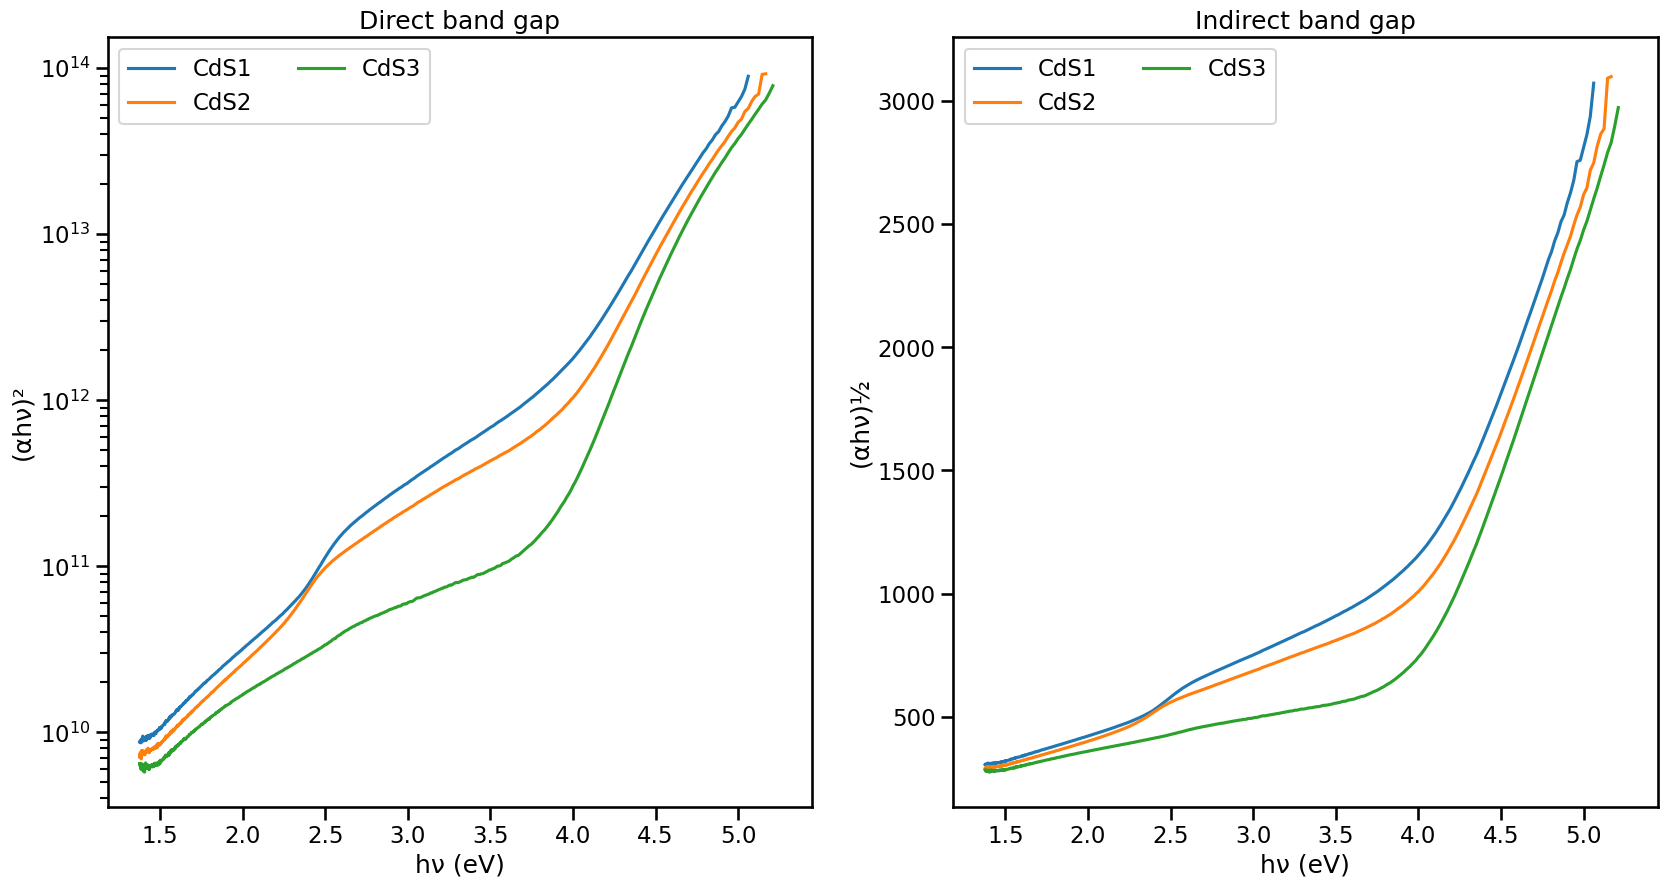

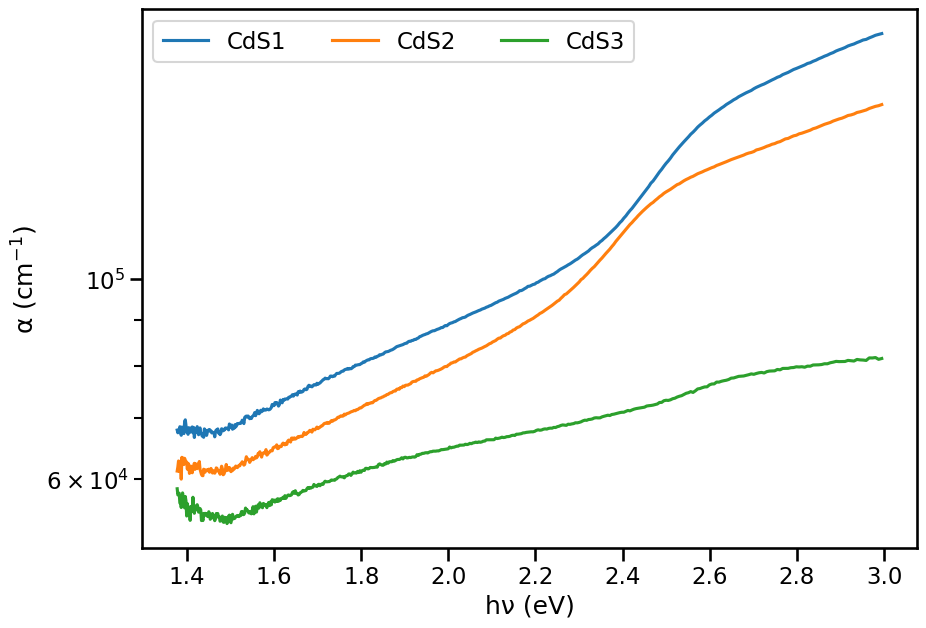

In [1]:
#Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import glob as gl
import seaborn as sns
import os

# File path to the Excel file
FILE_PATH = "C:/Users/jp_ol/OneDrive/Ambiente de Trabalho/TESE/Data_Analysis/data/UV-Vis/CdS_JOliveira_7abr26.xlsx"

# Set output directory for plots
PLOTS_DIR = "Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Physical constants
h = 6.62607015e-34  # Planck's constant (J·s)
c = 299792458       # Speed of light (m/s)
e = 1.602176634e-19 # Elementary charge (C)

# Load all sheets from Excel
xls = pd.ExcelFile(FILE_PATH)
sheet_names = xls.sheet_names

# Dictionary to store processed data
res = {}

sns.set_context('talk')

#Create the Tauc plots for all the samples
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
fig1, ax3 = plt.subplots(1, 1, figsize=(10, 7))

for sheet_name in sheet_names:
        # Read the sheet
        df = pd.read_excel(FILE_PATH, sheet_name=sheet_name)
        
        # Get wavelength and optical properties
        wavelength = df['wavelength'].values
        
        # Determine which columns contain T and R
        if 'T' in df.columns:
            transmittance = df['T'].values /100  # Convert percentage to fraction
        else:
            transmittance = df.iloc[:, 1].values /100  # Assume second column is T and convert to fraction
            
        if 'R' in df.columns:
            reflectance = df['R'].values /100  # Convert percentage to fraction
        else:
            reflectance = df.iloc[:, 2].values /100  # Assume third column is R and convert to fraction
        
        # Get thickness (in nm, convert to cm)
        if 'thickness' in df.columns:
            thickness_nm = df['thickness'].dropna().iloc[0]
        
        # Calculate absorption coefficient using the formula:
        # α = (1/t) * ln((1-R)²/T + sqrt((1-R)⁴/(4T²) + R²))
        #                |---------------rt---------------|    

        rt = (1 - reflectance)**2/(transmittance) + np.sqrt( (1 - reflectance)**4/(4*transmittance**2) +  reflectance**2  )

        x = (h * c)/ (wavelength * 10**-9) / e
        data_y = np.where(rt <= 0, 1E-10, rt)

        y = np.log(data_y)/ (thickness_nm * 1e-7)  # Convert nm to cm
        y_DA = (y*x)**(2)
        y_IA = (y*x)**(1/2)

        # Store in dictionary
        res[sheet_name] = {
            'hv': x,
            'alpha': y, # Store the calculated alpha values
            'DA': np.nan_to_num(y_DA),
            'IA': np.nan_to_num(y_IA),
            'nm': wavelength,
            'R': reflectance,
            'T': transmittance
        }
        
        # Plot the data
        ax1.plot(x,y_DA, label=sheet_name)
        ax2.plot(x,y_IA, label=sheet_name)

        #absorbance plot
        small_range_y = y[x<3]
        small_range_x = x[x<3]
        ax3.plot(small_range_x, small_range_y, label=sheet_name)

# Fix the graph of direct band gap
ax1.legend(ncols=2)
ax1.set_ylabel(r'(αhν)²')
ax1.set_xlabel(r'hν (eV)')
ax1.set_title('Direct band gap')
ax1.set_yscale("log")

# Fix the graph of indirect band gap
ax2.legend(ncols=2)
ax2.set_ylabel(r'(αhν)½')
ax2.set_xlabel(r'hν (eV)')
ax2.set_title('Indirect band gap')

# Fix the graph of indirect band gap
ax3.legend(ncols=3)
ax3.set_ylabel(r'α (cm$^{-1}$)')
ax3.set_xlabel(r'hν (eV)')
ax3.set_yscale("log")
#ax3.set_xlim([0,3])

# Save the values of the tauc plot in excel files
with pd.ExcelWriter(os.path.join(PLOTS_DIR, "results_tauc_plot.xlsx")) as writer:
  for label_plot, data in res.items():
      df_export = pd.DataFrame(data)
      df_export.to_excel(writer, index=False, sheet_name=label_plot )

# Save the combined plots
fig.savefig(os.path.join(PLOTS_DIR, 'Combined_Direct_Indirect_BandGap.png'), dpi=300, bbox_inches='tight')
fig1.savefig(os.path.join(PLOTS_DIR, 'Absorption_Coefficient.png'), dpi=300, bbox_inches='tight')

plt.show()

## Band Gap Extraction
### Procedure

1. **Data Smoothing**: Apply Savitzky-Golay filter to reduce noise
2. **Linear Region Identification**: Find the region with maximum slope (derivative) in the Tauc plot
3. **Extrapolation**: Fit a line through the linear region
4. **Band Gap Extraction**: The x-intercept (where y=0) gives the optical band gap $E_g$



Calculating Bandgaps...


c:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\.venv\Lib\site-packages\matplotlib\axes\_base.py:3070: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


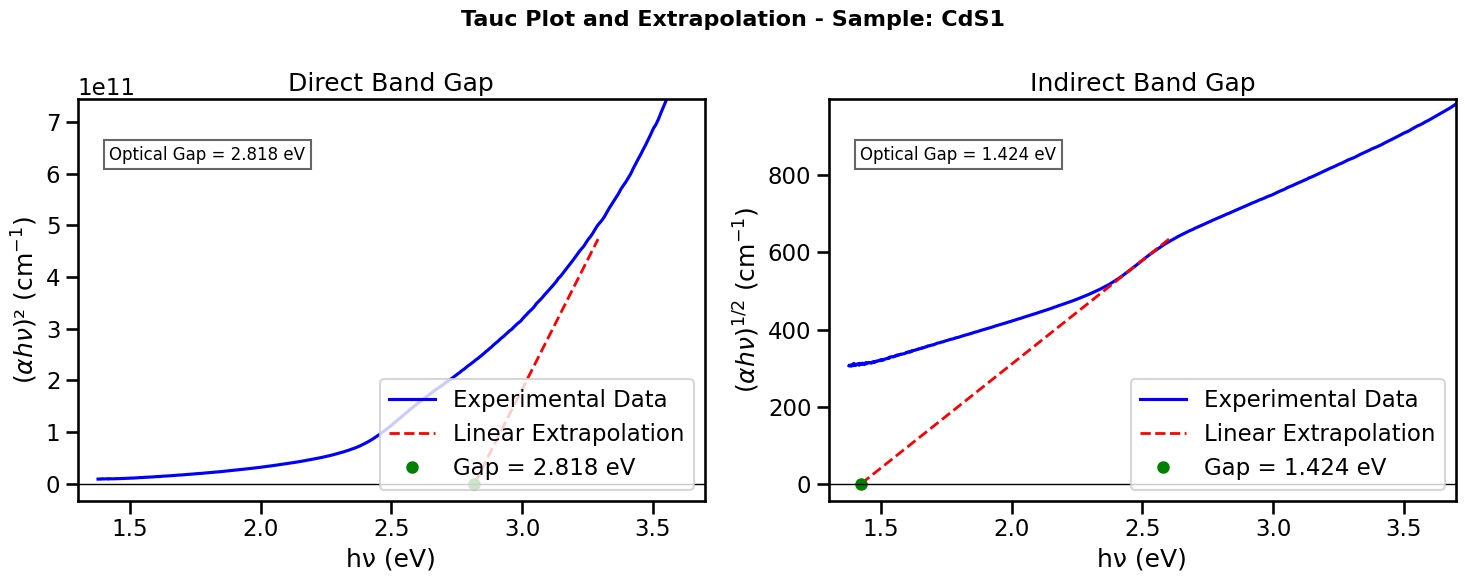

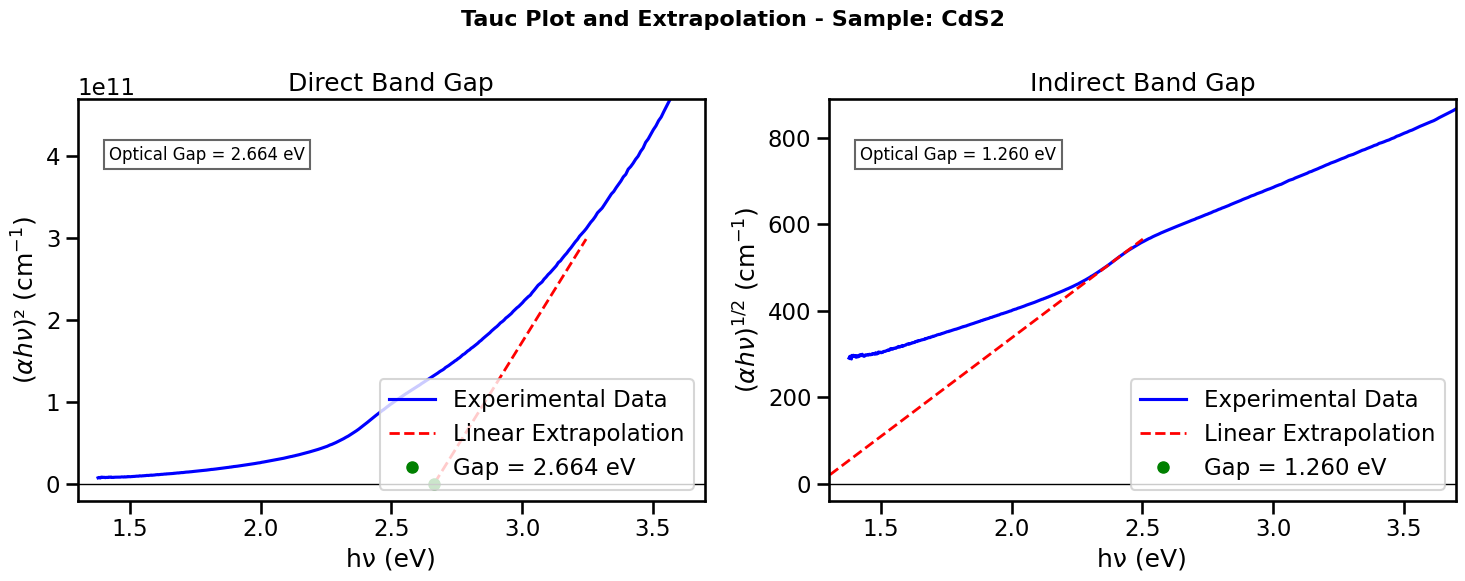

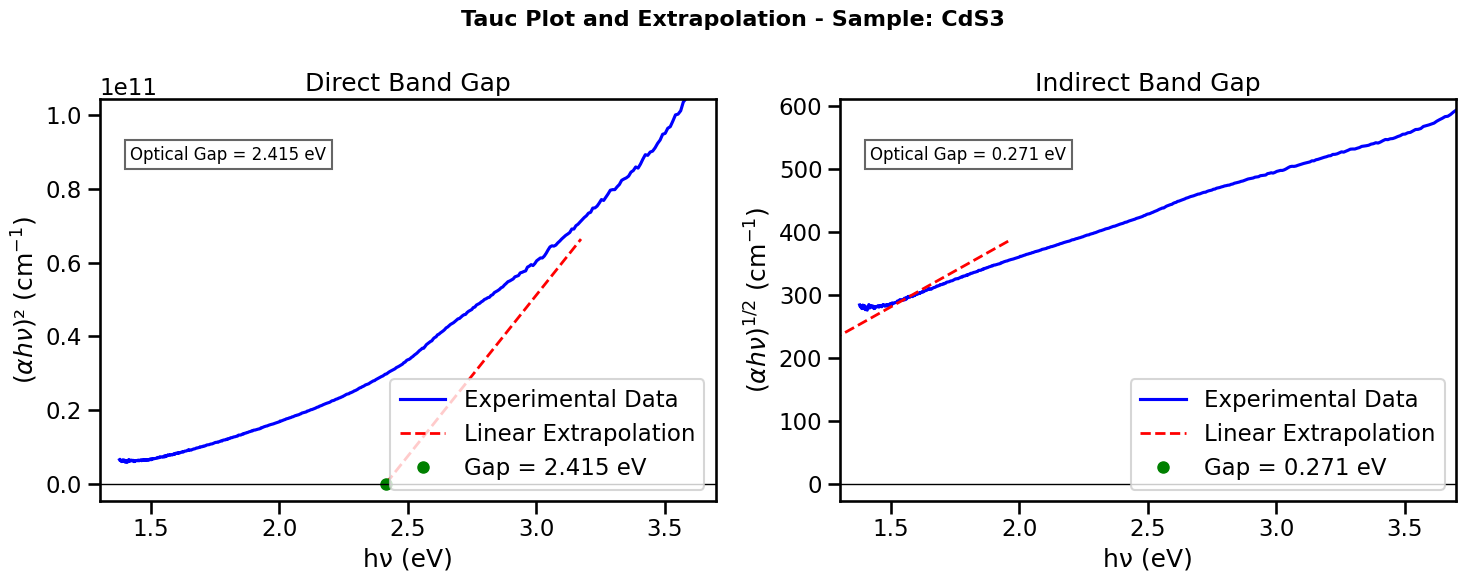


--- Summary of Calculated Bandgaps ---
Sample     Type  Gap (eV)
  CdS1   Direct  2.818063
  CdS1 Indirect  1.424397
  CdS2   Direct  2.663892
  CdS2 Indirect  1.259554
  CdS3   Direct  2.414828
  CdS3 Indirect  0.270624
Summary saved in folder: Plots


In [2]:
from scipy.signal import savgol_filter
import os

print("\nCalculating Bandgaps...")
gaps = []

# You can adjust these limits (in eV) to focus the analysis on the rising edge of the material
# and ignore noise at low energies or substrate (Glass) absorption at high energies.
min_energy = 1.5 
max_energy = 3.5 

for k in res.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    fig.suptitle(f'Tauc Plot and Extrapolation - Sample: {k}', fontsize=16, fontweight='bold')

    x_hv = res[k]['hv']
    
    # Extrapolation for both Direct (ax1) and Indirect (ax2) Bandgaps
    plots_info = [
        {'ax': ax1, 'y_data': res[k]['DA'], 'title': 'Direct Band Gap', 'ylabel': r'$(αhν)²$ (cm$^{-1}$)'},
        {'ax': ax2, 'y_data': res[k]['IA'], 'title': 'Indirect Band Gap', 'ylabel': r'$(αhν)^{1/2}$ (cm$^{-1}$)'}
    ]

    for info in plots_info:
        ax = info['ax']
        y_data = info['y_data']

        # 1. Filter the data only for the region of interest (avoid noise at the edges)
        mask = (x_hv >= min_energy) & (x_hv <= max_energy)
        x_fit = x_hv[mask]
        y_fit = y_data[mask]

        if len(x_fit) < 10:
            ax.text(0.5, 0.5, 'Insufficient data in the region', transform=ax.transAxes)
            continue

        # 2. Smooth the data to obtain a clean derivative (Savitzky-Golay Filter)
        # The window size must be odd
        window_len = min(25, len(y_fit) - (1 if len(y_fit) % 2 == 0 else 0))
        if window_len > 2:
            y_smooth = savgol_filter(y_fit, window_length=window_len, polyorder=2)
        else:
            y_smooth = y_fit

        # 3. Calculate the First Derivative (Gradient)
        d1 = np.gradient(y_smooth, x_fit)

        # 4. Find the point of maximum slope (linear region of the Tauc Plot)
        max_idx = np.argmax(d1)
        x_0 = x_fit[max_idx]
        y_0 = y_smooth[max_idx]
        m = d1[max_idx] # The slope (m)

        # 5. Extrapolation line equation: y = m*x + c  =>  c = y_0 - m*x_0
        c = y_0 - m * x_0

        # 6. Calculate the Optical Bandgap (X-axis intersection, where y = 0)
        # 0 = m*x + c => x = -c/m
        x_cross = -c / m
        
        # Save the values
        gap_type = 'Direct' if 'Direct' in info['title'] else 'Indirect'
        gaps.append({'Sample': k, 'Type': gap_type, 'Gap (eV)': x_cross})

        # 7. Draw the plots
        # Plot original data
        ax.plot(x_hv, y_data, 'b-', label='Experimental Data')
        
        # Plot extrapolation line (dashed red)
        y_max_plot = 0.7 * np.amax(y_fit) # Raise the line up to 70% of the maximum peak
        x_line_start = x_cross
        x_line_end = (y_max_plot - c) / m
        
        ax.plot([x_line_start, x_line_end], [0, y_max_plot], 'r--', linewidth=2, label='Linear Extrapolation')
        
        # Mark the exact point of the Bandgap
        ax.plot(x_cross, 0, 'go', markersize=8, label=f'Gap = {x_cross:.3f} eV')
        
        # Axis formatting
        ax.axhline(0, color='black', linewidth=1)
        ax.set_xlabel(r'hν (eV)')
        ax.set_ylabel(info['ylabel'])
        ax.set_title(info['title'])
        ax.text(0.05, 0.85, f'Optical Gap = {x_cross:.3f} eV', transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.6))
        
        # Adjust the visual "window" of the plot
        ax.set_xlim(min_energy - 0.2, max_energy + 0.2)
        ax.set_ylim(-0.05 * np.amax(y_fit), 1.1 * np.amax(y_fit))
        ax.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'Tauc_plot_extrapolation_{k}.png'), dpi=300)
    plt.show()

# Export a summary with all calculated Bandgaps
print("\n--- Summary of Calculated Bandgaps ---")
df_gaps = pd.DataFrame(gaps)
print(df_gaps.to_string(index=False))

# Optional: Save to an Excel file
df_gaps.to_excel(os.path.join(PLOTS_DIR, "Summary_Bandgaps.xlsx"), index=False)
print(f"Summary saved in folder: {PLOTS_DIR}")

## 1. Why do we need to smooth the data?
In the case of the Tauc Plot, our goal in automatically finding the bandgap is to identify the region where the curve rises most steeply and linearly (the linear absorption region). Mathematically, we find the maximum slope by calculating the first derivative (the gradient) of the data and looking for the point where this derivative is at its maximum (which is what the np.argmax(d1) function does).

The problem is that the data coming out of the spectrophotometer is never mathematically a perfect line. They always have tiny oscillations caused by electronic noise, dust, or the detection limits of the equipment.

The derivative measures the difference between two consecutive points. If there is a small "jump" caused by noise between two points that are very close to each other on the X-axis, the slope between them will appear almost vertical.

The result is that the derivative of a noisy signal becomes full of random "spikes".

If we don't smooth the data first, the code would pick up one of these random noise spikes and declare it as the point of maximum slope, completely missing the actual ramp of the material (CdS).

## 2. What is the [Savitzky-Golay](https://www.bing.com/ck/a?!&&p=3d75b514299838f9d857d340f6910c4cc865649feb3be675d409aa57dbe44156JmltdHM9MTc3NjAzODQwMA&ptn=3&ver=2&hsh=4&fclid=39247e5c-644c-6408-2947-6a0b652b6592&psq=savitzky-golay+smoothing&u=a1aHR0cHM6Ly9laWdlbnZlY3Rvci5jb20vd3AtY29udGVudC91cGxvYWRzLzIwMjAvMDEvU2F2aXR6a3lHb2xheS5wZGY) method?
Invented in 1964 by Abraham Savitzky and Marcel Golay, it is a highly digital filtering algorithm, especially in spectroscopy and analytical chemistry.

If we used a simple "moving average" to smooth the data, the curve would become smoother, but the corners and ramps would become "flattened out" (smeared) and we would lose the true slope of the curve. The Savitzky-Golay method does something much smarter:

Sliding Window: It looks at a small group of points at a time (the window_length parameter, which we set to 25 points).

Polynomial Fit: Within this window, instead of simply calculating the average, it tries to draw a mathematical curve (a polynomial, like a parabola or a 2nd-degree curve) that best fits those specific points using the least squares method.

Sliding: It replaces the central point with the value of that perfect curve and then slides the window one point forward, repeating the process for the entire graph.

The result: It manages to clean up high-frequency noise without distorting the real shape of the curve and, most importantly, it preserves the original slopes, which is absolutely crucial when our next step is to calculate a derivative to draw a tangent line.

## Sigmoid-Boltzmann Function

Another way of determining the Eg, acording to [Zanatta](https://www.nature.com/articles/s41598-019-47670-y#Equ9), by doing a Sigmoid-Boltzmann fitting based on the absorption coefficient previously calculated can be done by the following function:

$$\alpha(E) = \alpha_{max} + \frac{\alpha_{min} - \alpha_{max}}{1 + \exp\left(\frac{E - E_0^{Boltz}}{δE}\right)} \quad (4)$$

where $\alpha_{min}$ and $\alpha_{max}$ stands for the minimum and maximum absorption coefficient respectively; $E_0^{Bolts}$ is the energy coordinate at which the absorption coefficient is halfway between $\alpha_{min}$ and $\alpha_{max}$; and $δE$ is associated with the slope of the sigmoid curve. In this case, 4 parameters will be optimized based on the absorption coefficient previously calculated ($\alpha_{comp}$) and the energy ($hν$) values.

After this, the direct and indirect band gap can be calculated as follows:

$$E_g^{dir} = E_0^{Boltz} - 0.3δE \quad (5)$$

$$E_g^{indir} = E_0^{Boltz} - 4.3δE \quad (6)$$

with 0.3 and 4.3 working as empirical constants determined by Zanatta from the corresponding direct and indirect results experimentally.


In [3]:
# ============================================================================
# SIGMOID-BOLTZMANN FUNCTION AND FITTING FUNCTIONS
# ============================================================================

def boltzman_function(x, a_max, a_min, e_boltz, dE):
  return a_max + ( (a_min-a_max)/(1+np.exp((x-e_boltz)/(dE)))  )


def num_of_zeros(n):
  s = '{:.16f}'.format(n).split('.')
  if s[0] == '0':
    # For numbers < 1, count the leading zeros and add 1
    return len(s[1]) - len(s[1].lstrip('0')) + 1
  else:
    # For numbers >= 1, no leading zeros needed
    return 0


from scipy.optimize import curve_fit

def fit_boltzmann(xdata, ydata, sample, xlims=[0.5, 2.5], guess_band_gap=1.7):  #Fit a Sigmoid-Boltzmann curve to absorption coefficient data and calculate band gaps.
  
  # Step 1: Remove data below the lower energy limit
  ydata = ydata[xdata > xlims[0]]
  xdata = xdata[xdata > xlims[0]]
  
  # Step 2: Remove data above the upper energy limit
  ydata = ydata[xdata < xlims[1]]
  xdata = xdata[xdata < xlims[1]]
  
  # Step 3: Remove any non-positive absorption values (must be > 0)
  ydata = ydata[ydata > 0]

  # _______ CURVE FITTING SECTION _______
  # Use scipy's curve_fit to fit the Sigmoid-Boltzmann function to the data
  # Try multiple optimization methods if one fails (robustness)
  
  try:
    # Attempt 1: Use 'dogbox' method - good for bounded problems
    # Initial parameter guess (p0): [max(data), min(data), guess_E_gap, slope=1]
    popt, pcov = curve_fit(boltzman_function, xdata, ydata, 
                           p0=[np.max(ydata), np.min(ydata), guess_band_gap, 1], 
                           method='dogbox')
  except:
    # Attempt 1 failed, try alternative method
    print('Fitting not possible with dogbox method, trying with trf method...')
    try:
      # Attempt 2: Use 'trf' method - Trust Region Reflective algorithm
      popt, pcov = curve_fit(boltzman_function, xdata, ydata, 
                             p0=[np.max(ydata), np.min(ydata), guess_band_gap, 1], 
                             method='trf')
    except:
      # Attempt 2 failed, try another method
      print('Fitting not possible with trf method, trying with lm method...')
      try:
        # Attempt 3: Use 'trf' method again (or could use 'lm' - Levenberg-Marquardt)
        popt, pcov = curve_fit(boltzman_function, xdata, ydata, 
                               p0=[np.max(ydata), np.min(ydata), guess_band_gap, 1], 
                               method='trf')
      except:
        # All fitting methods failed - plot the raw data and return None
        print('No fitting possible')
        plt.figure()
        plt.scatter(xdata, ydata, label='data', color='k', s=10)
        plt.ylabel(r'α(E)')
        plt.xlabel('Energy (eV)')
        plt.title('Sigmoid-Boltzmann failed fitting for sample: ' + sample)
        return None, None

  # Extract parameter uncertainties
  perr = np.sqrt(np.diag(pcov))

  plt.figure(figsize=(10, 8))
  plt.scatter(xdata, ydata, label='data', color='k', s=10)
  plt.plot(xdata, boltzman_function(xdata, *popt), 'r-',
           label='fit: a=%5.3f, b=%5.3f, c=%5.3f, d=%5.3f' % tuple(popt))
  plt.title('Sigmoid-Boltzmann fitting for sample: ' + sample)

  # _______ BAND GAP CALCULATION SECTION _______
  
  Eg_dir = (popt[2] - 0.3 * popt[-1])     # Direct band gap in eV
  Eg_ind = (popt[2] - 4.3 * popt[-1])     # Indirect band gap in eV

  # Calculate the uncertainty in the band gap by error propagation
  dEg = np.sqrt(perr[2]**2 + perr[-1]**2)

  # Determine appropriate number of decimal places for displaying the uncertainty
  decimals = num_of_zeros(dEg)

  plt.ylabel(r'α(E)')
  plt.xlabel('Energy (eV)')
  plt.text(0.05, 0.7, 
           r'Direct Optical Gap = ' + str(round(Eg_dir, decimals)) + r' ± ' + str(round(dEg, decimals)) + ' eV' + '\n'
           r'Indirect Optical Gap = ' + str(round(Eg_ind, decimals)) + r' ± ' + str(round(dEg, decimals)) + ' eV',
           transform=plt.gca().transAxes)
  plt.legend()
  plt.savefig(os.path.join(PLOTS_DIR, f'SB_' + sample + '.png'))
  plt.show()

  return popt, perr

Fitting not possible with dogbox method, trying with trf method...
Fitting not possible with trf method, trying with lm method...
No fitting possible
Fitting not possible with dogbox method, trying with trf method...
Fitting not possible with trf method, trying with lm method...
No fitting possible


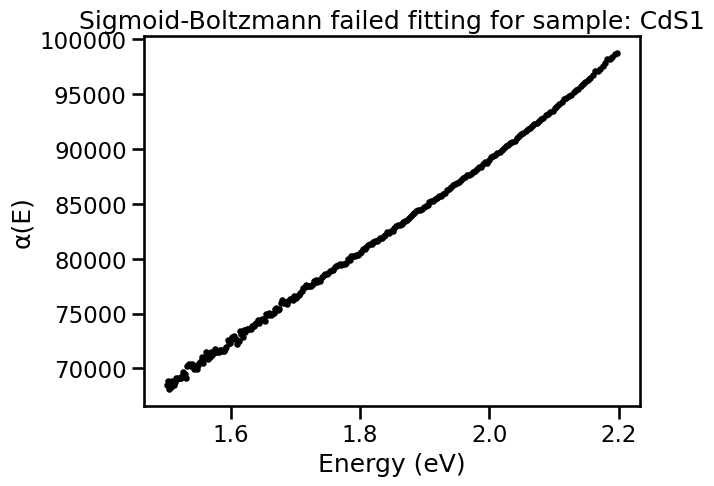

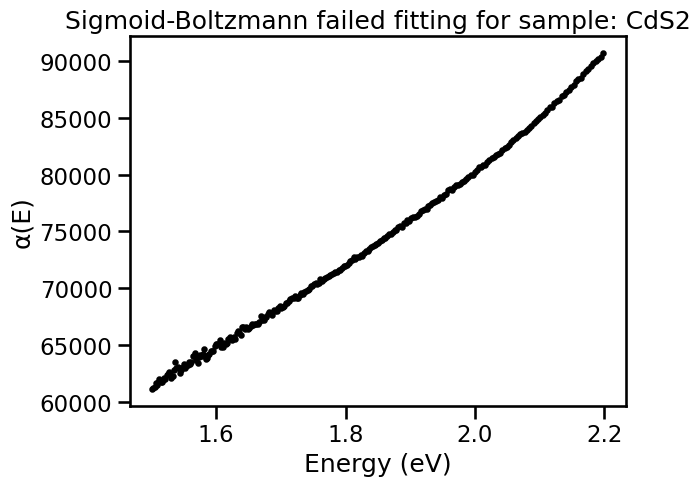

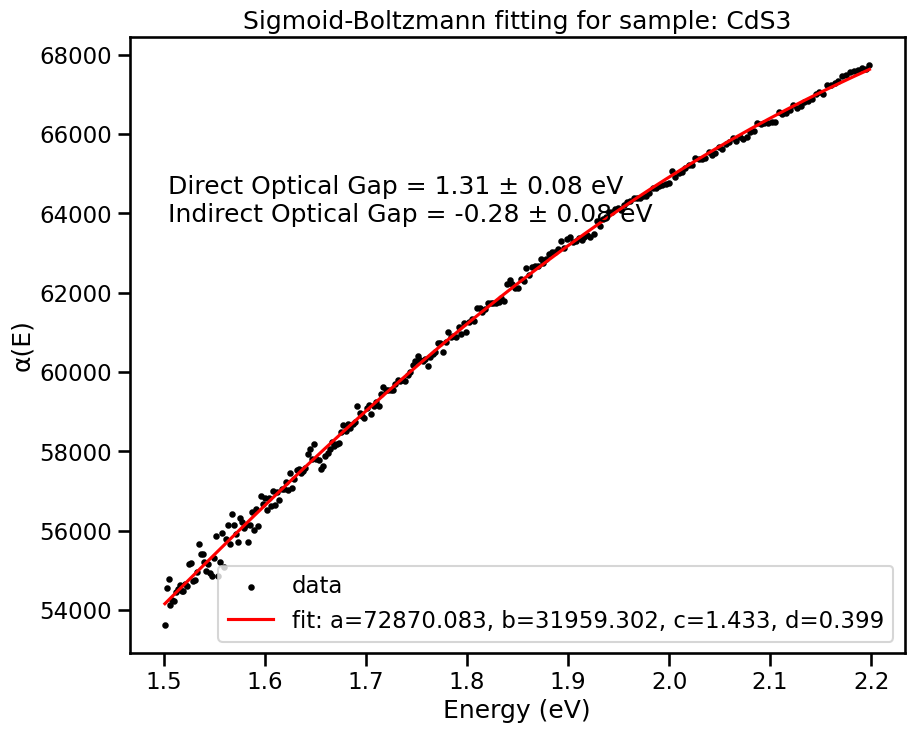

Sample: CdS3
  Direct Optical Gap = 1.31 ± 0.08 eV
  Indirect Optical Gap = -0.28 ± 0.08 eV




In [4]:
for sam_label, sam_data in res.items():
    xdata = sam_data['hv']
    ydata = sam_data['alpha'] # Use the stored alpha values for fitting

    popt_vals, perr_vals = fit_boltzmann(xdata, ydata, sam_label, [1.5,2.2], 1.8)

    if popt_vals is not None and perr_vals is not None:
        Eg_dir = (popt_vals[2] - 0.3 * popt_vals[-1])
        Eg_ind = (popt_vals[2] - 4.3 * popt_vals[-1])
        dEg = np.sqrt(perr_vals[2]**2 + perr_vals[-1]**2)
        decimals = num_of_zeros(dEg)

        print(f"Sample: {sam_label}")
        print(f"  Direct Optical Gap = {round(Eg_dir, decimals)} \u00B1 {round(dEg, decimals)} eV")
        print(f"  Indirect Optical Gap = {round(Eg_ind, decimals)} \u00B1 {round(dEg, decimals)} eV")
        print("\n")
     

## SCAPS absorption file

Creation of the absorption file (.abs) to use on SCAPS.

Creating SCAPS absorption files...
✓ Created: Plots\SCAPS_Absorption\CdS1_SCAPS_absorption.abs
✓ Plot saved: Plots\SCAPS_Absorption\CdS1_SCAPS_absorption_plot.png


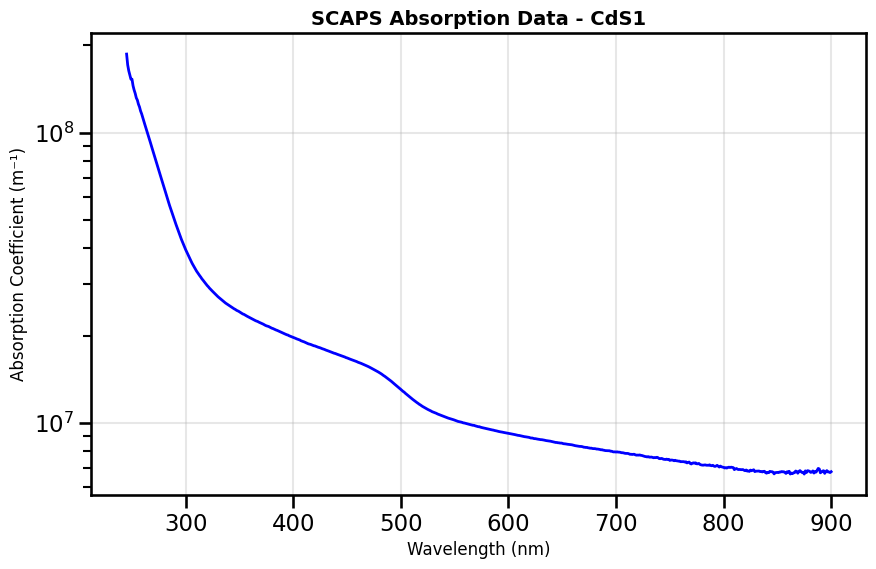

✓ Created: Plots\SCAPS_Absorption\CdS2_SCAPS_absorption.abs
✓ Plot saved: Plots\SCAPS_Absorption\CdS2_SCAPS_absorption_plot.png


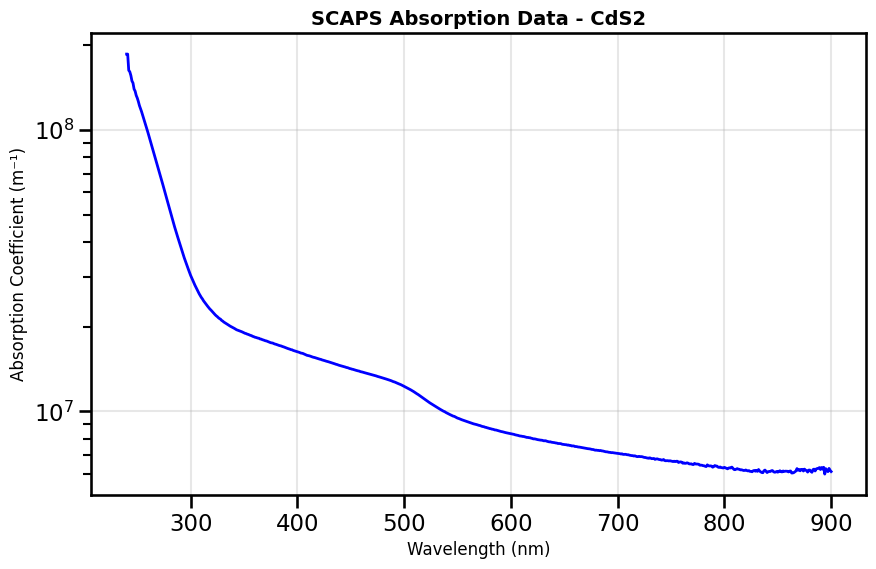

✓ Created: Plots\SCAPS_Absorption\CdS3_SCAPS_absorption.abs
✓ Plot saved: Plots\SCAPS_Absorption\CdS3_SCAPS_absorption_plot.png


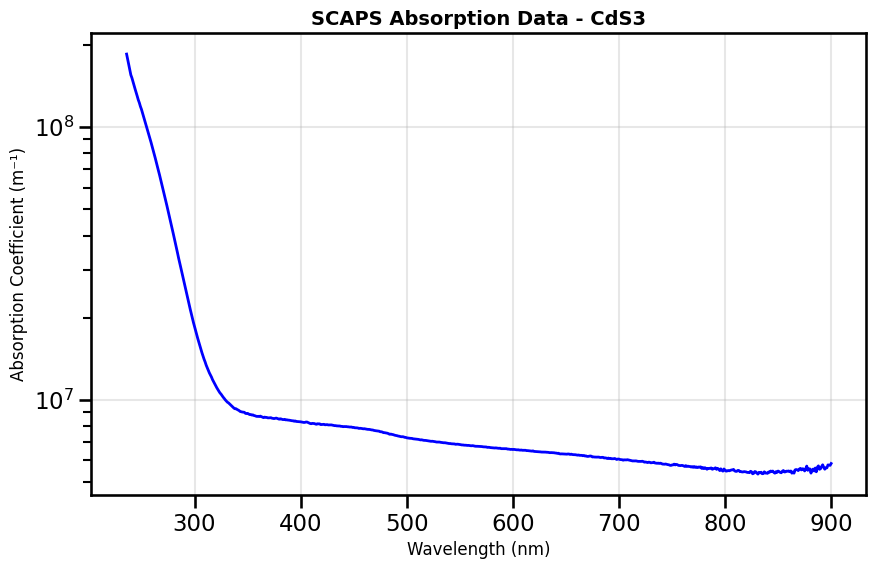


All SCAPS absorption files and plots saved in: Plots\SCAPS_Absorption


In [5]:
# Create SCAPS absorption files with wavelength and absorption coefficient
scaps_dir = os.path.join(PLOTS_DIR, "SCAPS_Absorption")
os.makedirs(scaps_dir, exist_ok=True)

print("Creating SCAPS absorption files...")

for sheet_name, data in res.items():
    # Extract wavelength (nm) and absorption coefficient (cm^-1)
    wavelength_nm = data['nm']
    absorption_coeff = data['alpha'] * 100  # Convert from cm^-1 to m^-1 for SCAPS
    
    # Create a dataframe with the two columns
    df_scaps = pd.DataFrame({
        'lambda[nm]': wavelength_nm,
        'alpha[m^-1]': absorption_coeff
    })
    
    # Create filename based on sheet name
    filename = os.path.join(scaps_dir, f"{sheet_name}_SCAPS_absorption.abs")
    
    # Save as text file with tabulated format, filtering out infinite values
    with open(filename, 'w') as f:
        f.write(f"/SCAPS Absorption Data - {sheet_name}\n")
        f.write("/lambda[nm]\talpha[m^-1]\n")
        
        for wl, alpha in zip(wavelength_nm, absorption_coeff):
            # Only write if alpha is a finite number (not inf, -inf, or nan)
            if np.isfinite(alpha):
                f.write(f"{wl:.2f}\t{alpha:.6e}\n")
    
    print(f"✓ Created: {filename}")
    
    # Generate plot for each sample
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Filter out non-finite values for plotting
    mask = np.isfinite(absorption_coeff)
    wavelength_clean = wavelength_nm[mask]
    absorption_clean = absorption_coeff[mask]
    
    ax.plot(wavelength_clean, absorption_clean, 'b-', linewidth=2)
    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Absorption Coefficient (m⁻¹)', fontsize=12)
    ax.set_title(f'SCAPS Absorption Data - {sheet_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Save the plot
    plot_filename = os.path.join(scaps_dir, f"{sheet_name}_SCAPS_absorption_plot.png")
    fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {plot_filename}")
    
    plt.show()

print(f"\nAll SCAPS absorption files and plots saved in: {scaps_dir}")